In [1]:
!pip install -q transformers datasets evaluate accelerate scikit-learn pandas numpy matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.8 MB/s eta 0:00:00


In [2]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import seaborn as sns
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

## 1. Dataset Loading



In [3]:
ds = load_dataset("davanstrien/WELFake")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-290868f0a36350(…):   0%|          | 0.00/152M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/72134 [00:00<?, ? examples/s]

In [4]:
print(ds)

DatasetDict({
    train: Dataset({
        features: ['title', 'text', 'label'],
        num_rows: 72134
    })
})


In [5]:
#transformation de ds a dataFrame
df = ds["train"].to_pandas()

In [6]:
print(df.shape)

(72134, 3)


## 2. Exploratory Data Analysis

In [7]:
print(df.columns)

Index(['title', 'text', 'label'], dtype='object')


In [8]:
df.head()

,title,text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,None,Did they post their votes for Hillary already?,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [9]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72134 entries, 0 to 72133
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   71576 non-null  object
 1   text    72095 non-null  object
 2   label   72134 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 1.7+ MB
None


In [10]:
print(df.describe())

              label
count  72134.000000
mean       0.514404
std        0.499796
min        0.000000
25%        0.000000
50%        1.000000
75%        1.000000
max        1.000000


In [11]:
print(df["label"].value_counts())

label
1    37106
0    35028
Name: count, dtype: int64


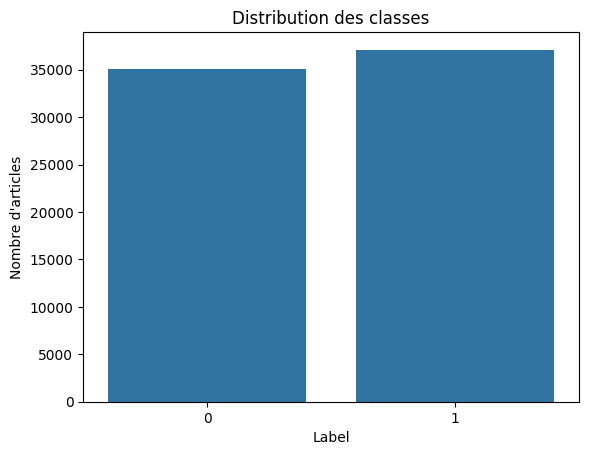

In [12]:
sns.countplot(data=df, x="label")

plt.title("Distribution des classes")
plt.xlabel("Label")
plt.ylabel("Nombre d'articles")
plt.show()

In [13]:
df.sample()

,title,text,label
20150,Nasty Women,Recipient Email => \nDonald Trump grabbed a ...,1


In [14]:
df.sample(5)

,title,text,label
66432,Cambodia goes all-in on China in casino port city,"SIHANOUKVILLE, Cambodia (Reuters) - Between Si...",0
18475,"A Voice of Christmas Past Returns, Asking for ...",This year’s holiday advertising campaign for t...,0
27797,Zika Deal in Congress Likely to Be Delayed Unt...,WASHINGTON — Emergency financing to fight t...,0
21805,JOE BIDEN Called McCain Urged Him to Vote Agai...,THE OLD GUARD DEMOCRATS BROUGHT ON THE FULL CO...,1
6128,"Report shows 1,300 unfilled jobs, strain for G...",BERLIN (Reuters) - The German military s procu...,0


In [15]:
df.tail()

,title,text,label
72129,Russians steal research on Trump in hack of U....,WASHINGTON (Reuters) - Hackers believed to be ...,0
72130,WATCH: Giuliani Demands That Democrats Apolog...,"You know, because in fantasyland Republicans n...",1
72131,Migrants Refuse To Leave Train At Refugee Camp...,Migrants Refuse To Leave Train At Refugee Camp...,0
72132,Trump tussle gives unpopular Mexican leader mu...,MEXICO CITY (Reuters) - Donald Trump’s combati...,0
72133,Goldman Sachs Endorses Hillary Clinton For Pre...,Goldman Sachs Endorses Hillary Clinton For Pre...,1


In [16]:
print(df.duplicated().sum())

8456


In [17]:
# Nombre de doublons avant suppression
print("Doublons title + text :", df.duplicated(subset=["title", "text"]).sum())

# Suppression des doublons
df = df.drop_duplicates(subset=["title", "text"]).reset_index(drop=True)

print("Doublons restants :", df.duplicated(subset=["title", "text"]).sum())

Doublons title + text : 8456
Doublons restants : 0


In [18]:
print(df.isnull().sum())

title    518
text      39
label      0
dtype: int64


In [19]:
both_missing = df["title"].isna() & df["text"].isna()

print("Titre ET texte manquants :", both_missing.sum())

Titre ET texte manquants : 0


In [20]:
df["title"] = df["title"].fillna("")
df["text"] = df["text"].fillna("")

In [21]:
print(df.isnull().sum())

title    0
text     0
label    0
dtype: int64


In [22]:
df["article"] = (df["title"] + " " + df["text"]).str.strip()

In [23]:
df.head()

,title,text,label,article
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1,LAW ENFORCEMENT ON HIGH ALERT Following Threat...
1,,Did they post their votes for Hillary already?,1,Did they post their votes for Hillary already?
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0,"Bobby Jindal, raised Hindu, uses story of Chri..."
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1,SATAN 2: Russia unvelis an image of its terrif...


In [24]:
df["length"] = df["article"].apply(lambda x: len(x) - x.count(" "))

In [25]:
print(df["length"].describe())

count     63678.000000
mean       2789.244402
std        3021.568393
min           1.000000
25%        1251.000000
50%        2107.000000
75%        3473.000000
max      122556.000000
Name: length, dtype: float64


<Axes: xlabel='length', ylabel='Density'>

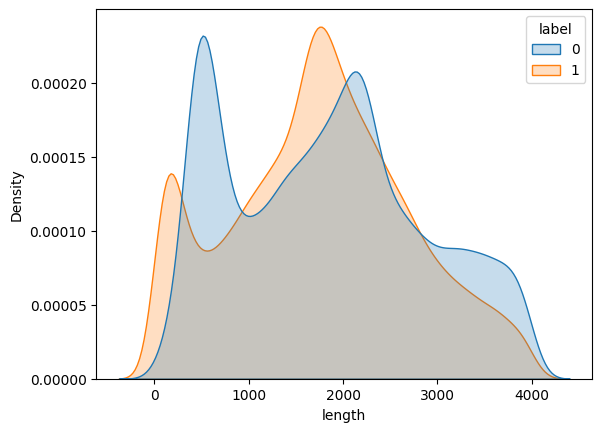

In [26]:
sns.kdeplot(data  = df[df['length'] < df['length'].quantile(0.80)], x= 'length', hue = 'label', fill = True)

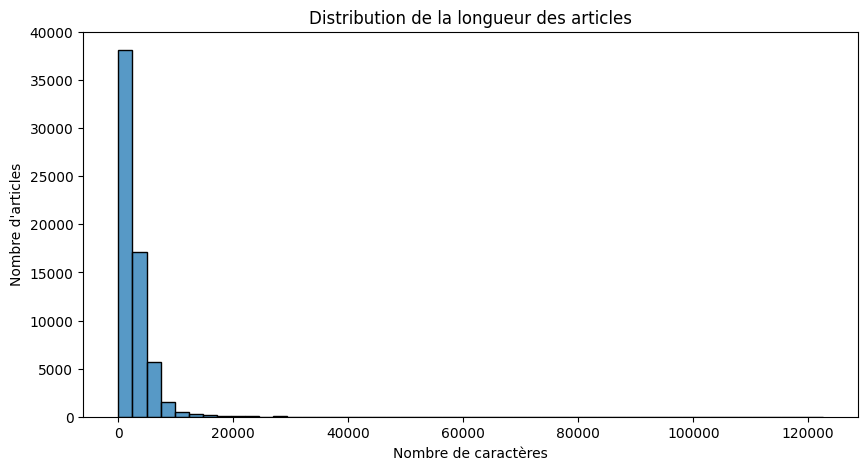

In [27]:
plt.figure(figsize=(10, 5))

sns.histplot(df["length"], bins=50)

plt.title("Distribution de la longueur des articles")
plt.xlabel("Nombre de caractères")
plt.ylabel("Nombre d'articles")
plt.show()

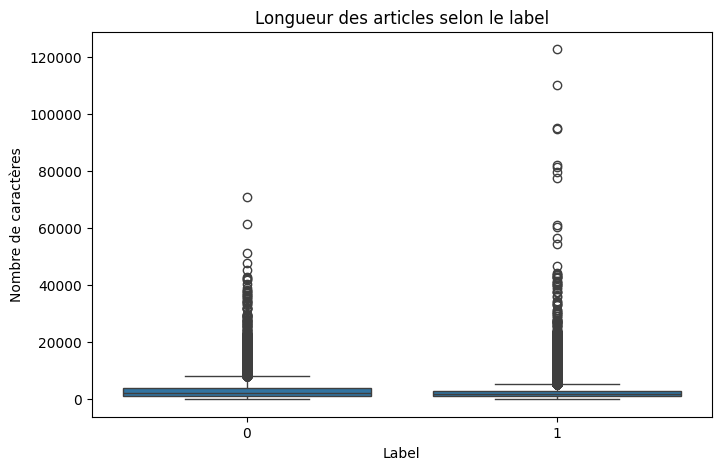

In [28]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="label", y="length")

plt.title("Longueur des articles selon le label")
plt.xlabel("Label")
plt.ylabel("Nombre de caractères")
plt.show()

In [29]:
df["word_count"] = df["article"].apply(lambda x: len(x.split()))

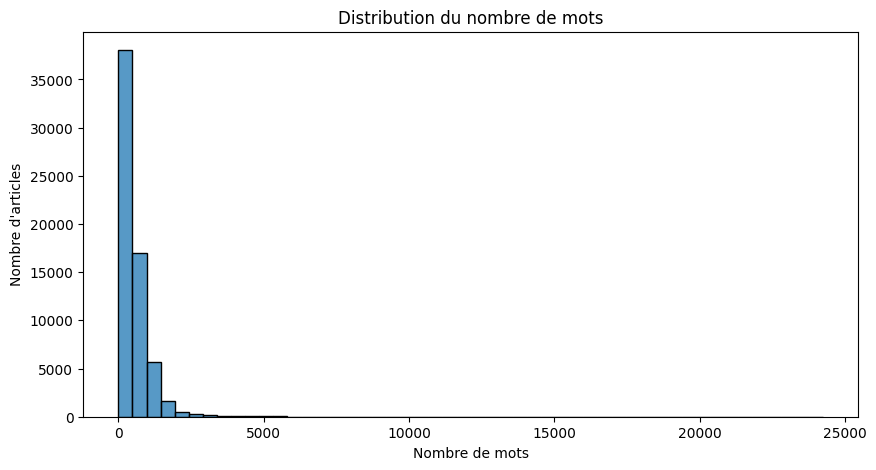

In [30]:
plt.figure(figsize=(10, 5))

sns.histplot(data=df, x="word_count", bins=50)

plt.title("Distribution du nombre de mots")
plt.xlabel("Nombre de mots")
plt.ylabel("Nombre d'articles")
plt.show()

## 3. Train / Validation / Test Split


In [31]:
X, y = df['article'], df['label']

In [32]:

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

## 4. Approach A — TF-IDF + Logistic Regression


In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [34]:
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    max_features=50000
)

In [35]:
X_train_tfidf = tfidf.fit_transform(X_train)

In [37]:
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

In [38]:
from sklearn.linear_model import LogisticRegression


In [39]:
lr = LogisticRegression(
    max_iter=1000
)

lr.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [40]:
y_pred = lr.predict(X_test_tfidf)

In [41]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96      3479
           1       0.95      0.95      0.95      2889

    accuracy                           0.95      6368
   macro avg       0.95      0.95      0.95      6368
weighted avg       0.95      0.95      0.95      6368



In [42]:
from sklearn.metrics import accuracy_score, f1_score

# Prédictions
y_train_pred = lr.predict(X_train_tfidf)
y_val_pred = lr.predict(X_val_tfidf)
y_test_pred = lr.predict(X_test_tfidf)

# Résultats
print("TRAIN")
print("Accuracy :", accuracy_score(y_train, y_train_pred))
print("F1       :", f1_score(y_train, y_train_pred))

print("\nVALIDATION")
print("Accuracy :", accuracy_score(y_val, y_val_pred))
print("F1       :", f1_score(y_val, y_val_pred))

print("\nTEST")
print("Accuracy :", accuracy_score(y_test, y_test_pred))
print("F1       :", f1_score(y_test, y_test_pred))

TRAIN
Accuracy : 0.966530564171018
F1       : 0.9630816534222549

VALIDATION
Accuracy : 0.9513190954773869
F1       : 0.9461431549687283

TEST
Accuracy : 0.9524183417085427
F1       : 0.9475506318158213


## 5. Approach B — Frozen DistilBERT


In [43]:
!pip install -q transformers datasets torch scikit-learn

In [44]:
model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

print("Device:", device)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Device: cuda


In [50]:
def get_embeddings(texts, tokenizer, model, batch_size=32, max_length=128):

    model.eval()
    device = next(model.parameters()).device

    embeddings = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]

        inputs = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        )

        # Move inputs to the same device as the model
        inputs = {key: value.to(device) for key, value in inputs.items()}

        with torch.no_grad():
            outputs = model(**inputs)

        # Mean pooling
        token_embeddings = outputs.last_hidden_state
        attention_mask = inputs["attention_mask"].unsqueeze(-1)

        masked_embeddings = token_embeddings * attention_mask
        sum_embeddings = masked_embeddings.sum(dim=1)
        sum_mask = attention_mask.sum(dim=1)

        batch_embeddings = sum_embeddings / sum_mask

        embeddings.append(batch_embeddings.cpu())

    return torch.cat(embeddings)

In [54]:
X_train = X_train.fillna("").astype(str).tolist()
X_train_emb = get_embeddings(
    X_train,
    tokenizer,
    model
)

<class 'pandas.core.series.Series'>
25910    Mueller removed FBI agent from Russia probe fo...
4946     Two U.S. Marines Under Investigation For Threa...
8428     LIBERAL LUNATIC CHRIS MATTHEWS Scolded By Pier...
9229     RNC Creates Obstructionist Force To Stop Obama...
27856    Bernie Sanders Has PERFECT Response To Man Ran...
Name: article, dtype: object


In [57]:
X_val = X_val.fillna("").astype(str).tolist()
X_test = X_test.fillna("").astype(str).tolist()
X_val_emb = get_embeddings(
    X_val,
    tokenizer,
    model
)

X_test_emb = get_embeddings(
    X_test,
    tokenizer,
    model
)

In [58]:
X_train_emb = X_train_emb.numpy()
X_val_emb = X_val_emb.numpy()
X_test_emb = X_test_emb.numpy()

In [59]:
print(X_train_emb.shape)
print(X_val_emb.shape)
print(X_test_emb.shape)

(50942, 768)
(6368, 768)
(6368, 768)


In [60]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

lr_model.fit(X_train_emb, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [61]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_val_pred = lr_model.predict(X_val_emb)

print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))

Validation Accuracy: 0.9525753768844221

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      3479
           1       0.95      0.95      0.95      2889

    accuracy                           0.95      6368
   macro avg       0.95      0.95      0.95      6368
weighted avg       0.95      0.95      0.95      6368



In [62]:
y_test_pred = lr_model.predict(X_test_emb)

print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

Test Accuracy: 0.9480213567839196

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.95      0.95      3479
           1       0.94      0.95      0.94      2889

    accuracy                           0.95      6368
   macro avg       0.95      0.95      0.95      6368
weighted avg       0.95      0.95      0.95      6368



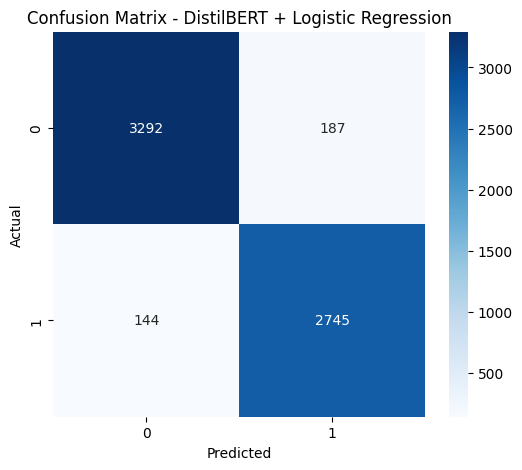

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - DistilBERT + Logistic Regression")
plt.show()

## 6. Approach C — Fine-tuned DistilBERT


In [64]:
from datasets import Dataset

train_dataset = Dataset.from_dict({
    "text": X_train,
    "label": y_train.tolist()
})

val_dataset = Dataset.from_dict({
    "text": X_val,
    "label": y_val.tolist()
})

test_dataset = Dataset.from_dict({
    "text": X_test,
    "label": y_test.tolist()
})

In [65]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

In [66]:
train_tokenized = train_dataset.map(
    tokenize_function,
    batched=True
)

val_tokenized = val_dataset.map(
    tokenize_function,
    batched=True
)

test_tokenized = test_dataset.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/50942 [00:00<?, ? examples/s]

Map:   0%|          | 0/6368 [00:00<?, ? examples/s]

Map:   0%|          | 0/6368 [00:00<?, ? examples/s]

In [73]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [74]:
print(type(model))

<class 'transformers.models.distilbert.modeling_distilbert.DistilBertForSequenceClassification'>


In [82]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary",
        zero_division=0
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [84]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./distilbert-finetuned",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=3,

    weight_decay=0.01,

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    logging_strategy="epoch",

    report_to="none"
)

In [85]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,

    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,

    processing_class=tokenizer,

    compute_metrics=compute_metrics
)

In [86]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.034053,0.109721,0.989950,0.994746,0.983039,0.988858
2,0.019014,0.092074,0.991520,0.988288,0.993077,0.990677
3,0.003534,0.097040,0.992619,0.993403,0.990308,0.991853


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=4776, training_loss=0.018866793893689487, metrics={'train_runtime': 1231.8489, 'train_samples_per_second': 124.062, 'train_steps_per_second': 3.877, 'total_flos': 5061115666750464.0, 'train_loss': 0.018866793893689487, 'epoch': 3.0})

In [87]:
history = trainer.state.log_history

for entry in history:
    print(entry)

{'loss': 0.03405315073291261, 'grad_norm': 0.00979121495038271, 'learning_rate': 1.3337520938023451e-05, 'epoch': 1.0, 'step': 1592}
{'eval_loss': 0.1097208708524704, 'eval_accuracy': 0.9899497487437185, 'eval_precision': 0.9947460595446584, 'eval_recall': 0.9830391138802353, 'eval_f1': 0.9888579387186629, 'eval_runtime': 16.1403, 'eval_samples_per_second': 394.541, 'eval_steps_per_second': 12.329, 'epoch': 1.0, 'step': 1592}
{'loss': 0.019013646859020444, 'grad_norm': 0.005016090348362923, 'learning_rate': 6.6708542713567844e-06, 'epoch': 2.0, 'step': 3184}
{'eval_loss': 0.09207401424646378, 'eval_accuracy': 0.9915201005025126, 'eval_precision': 0.9882879779538408, 'eval_recall': 0.9930771893388716, 'eval_f1': 0.9906767955801105, 'eval_runtime': 16.3411, 'eval_samples_per_second': 389.693, 'eval_steps_per_second': 12.178, 'epoch': 2.0, 'step': 3184}
{'loss': 0.003533584089135405, 'grad_norm': 0.0007077830960042775, 'learning_rate': 4.1876046901172536e-09, 'epoch': 3.0, 'step': 4776}
{

In [88]:
test_results = trainer.evaluate(
    test_tokenized
)

print(test_results)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'eval_loss': 0.09404256194829941, 'eval_accuracy': 0.9923052763819096, 'eval_precision': 0.9933981931897151, 'eval_recall': 0.9896157840083074, 'eval_f1': 0.9915033813074389, 'eval_runtime': 17.3667, 'eval_samples_per_second': 366.679, 'eval_steps_per_second': 11.459, 'epoch': 3.0}


In [92]:
predictions = trainer.predict(
    test_tokenized
)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


In [95]:
y_test_pred = np.argmax(
    predictions.predictions,
    axis=1
)

In [96]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_test_pred,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.9914    0.9945    0.9930      3479
           1     0.9934    0.9896    0.9915      2889

    accuracy                         0.9923      6368
   macro avg     0.9924    0.9921    0.9922      6368
weighted avg     0.9923    0.9923    0.9923      6368



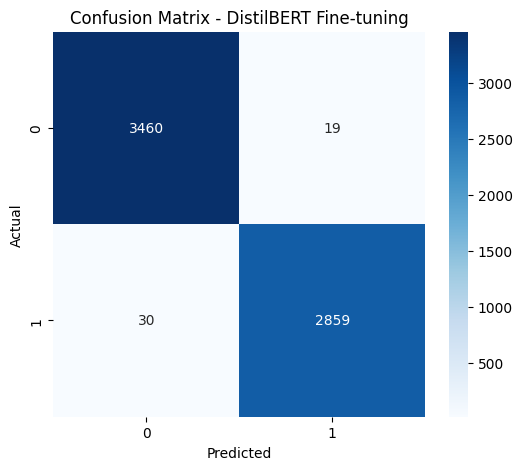

In [97]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(
    y_test,
    y_test_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - DistilBERT Fine-tuning")

plt.show()